# HW3 - Part 2

## 3.3: Gaussian State Preparation

In the following exercise we are going to implement circuits that prepare a gaussian state. Gaussian functions are fundamental for various quantum algorithms and applications, such as financial modeling, thermal state preparation and more. 

By preparing a gaussian state we look for a quantum circuit with effective unitary $U$ which fulfills:

$U |0\rangle = \sum_x {\sqrt{f(x)}|x\rangle}$ 

where $f(x)$ is a normalized gaussian, such that $\sum_x{f(x)}=1$.

Since we live in a discrete and finite space, we should choose a specific grid and truncation for our gaussian. We set $f(x) = \frac{e^{-0.5x^2}}{Z}$ ($Z$ is a normalization factor) as the wanted gaussian, with a grid $x \in[-4, 4)$ (the number of points in the grid is determined by `NUM_QUBITS`).

To make it clear, we plot the wanted discretization of the probability distribution:

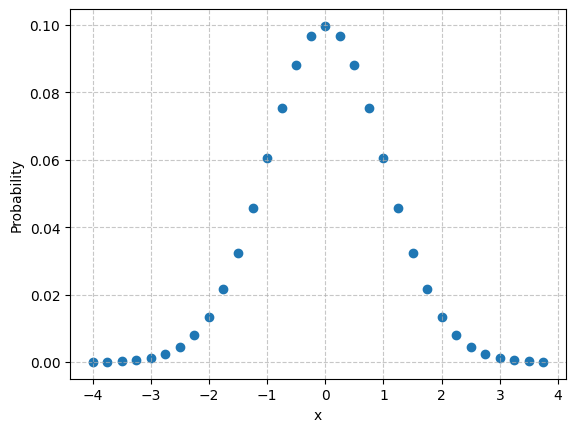

In [4]:
import numpy as np
import matplotlib.pyplot as plt

NUM_QUBITS = 5

FRACTION_DIGITS = NUM_QUBITS - 3 # Because we want the grid [-4, 4). 
EXP_RATE = 1/2

grid = np.linspace(-4, 4 - 8 / (2**NUM_QUBITS), 2**(NUM_QUBITS))

wanted_gaussian = np.exp(- EXP_RATE * grid**2)
wanted_gaussian /= np.sum(wanted_gaussian)  # Normalize the Gaussian

plt.scatter(grid, wanted_gaussian)
plt.xlabel('x')
plt.ylabel('Probability')
plt.grid(True, linestyle='--', alpha=0.7)

### Part A: load the gaussian using the `prepare_state` function

Using the `prepare_state` function, load the wanted gaussian state. Note that `x` is defined to be a signed integer (encoded with [2's-complement encoding](https://en.wikipedia.org/wiki/Two%27s_complement)).

In [10]:
from classiq import *
from classiq.interface import *
from classiq.applications import *
from classiq.open_library import *
from classiq.qmod import *
from classiq.executor import *
from classiq.model_expansions import *
from classiq.analyzer import *
from classiq.synthesis import *
from classiq.execution import *
import numpy as np

NUM_QUBITS = 5  # Increase for more probability states
FRACTION_DIGITS = NUM_QUBITS - 3  # Adjust for precision
EXP_RATE = 1/2  # Gaussian decay rate

# Generate the Gaussian distribution
grid = np.linspace(-4, 4 - 8 / (2**NUM_QUBITS), 2**(NUM_QUBITS))
wanted_gaussian = np.exp(-EXP_RATE * grid**2)
wanted_gaussian /= np.sum(wanted_gaussian)  # Normalize the Gaussian

# Swap the two halves of the Gaussian
half = len(wanted_gaussian) // 2
flipped_wanted_gaussian = np.concatenate((wanted_gaussian[half:], wanted_gaussian[:half]))

@qfunc
def prepare_gaussian_funcion_direct(x: QNum):
    inplace_prepare_state(x, flipped_wanted_gaussian.tolist(), 0)
    # prepare_state(probabilities=flipped_wanted_gaussian.tolist(), bound=0.01, out=x)

@qfunc
def main(x: Output[QNum[NUM_QUBITS, SIGNED, FRACTION_DIGITS]]):
    # allocate(x)
    # Prepare Gaussian state
    prepare_state(probabilities=flipped_wanted_gaussian.tolist(), bound=0.01, out=x)
    # prepare_gaussian_funcion_direct(x)
# Generate the quantum model with constraints
qmod = create_model(main,
                    execution_preferences=ExecutionPreferences(num_shots=1000000),
                    constraints=Constraints(max_width=25))

qprog = synthesize(qmod)

res = execute(qprog).result_value()
probs = np.zeros(len(flipped_wanted_gaussian))  # Adjust for full probability list
for sample in res.parsed_counts:
    probs[int(sample.state["x"])] = sample.shots / res.num_shots
print("Resulting probabilities:", probs)

res = execute(qprog).get_sample_result()

# show information about the synthesized circuit
circuit = QuantumProgram.from_qprog(qprog)
print("depth:", circuit.transpiled_circuit.depth, "width:", circuit.data.width)
print("counts:", circuit.transpiled_circuit.count_ops)


Resulting probabilities: [0.075193 0.021583 0.003312 0.000477 0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.000192 0.000185 0.003811 0.01749 ]
depth: 1112 width: 5
counts: {'u': 665, 'cx': 624}


In [6]:
def verify_results(parsed_counts, num_qubits):
    EXP_RATE = 1/2
    
    grid = np.linspace(-4, 4 - 8 / (2**NUM_QUBITS), 2**(NUM_QUBITS))
    
    wanted_gaussian = np.exp(- EXP_RATE * grid**2)
    wanted_gaussian /= np.sum(wanted_gaussian)  # Normalize the Gaussian

    x = [sample.state['x'] for sample in parsed_counts]
    probs = np.array([sample.shots for sample in parsed_counts])
    probs = probs/probs.sum()
    
    plt.scatter(grid, wanted_gaussian, color='blue',label = "wanted")
    plt.scatter(x, probs, color='red', marker='+', label = "sampled")
    plt.xlabel('x')
    plt.ylabel('Probability')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

#verify_results(res.parsed_counts, NUM_QUBITS)

### Part B: load the gaussian using amplitude loading

The first method we used is non-scalable, and we will build towards an efficient implementation. The approach is taken from another Grover's algorithm, termed ["black box state preparation"](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.85.1334).

The idea is to start with a uniform distribution over the state, and use amplitude loading to load a wanted probability function $f(x)$:
$$
\frac{1}{N}\sum_x{|x\rangle}|0\rangle_{ind} \rightarrow \frac{1}{N}\sum_x{|x\rangle(f(x)|1\rangle_{ind} + \sqrt{1-f^2(x)}|0\rangle}_{ind})
$$
Then post select\amplify the indicator qubit to get the desired distribution.

**Task:** using amplitude loading (i.e [`*=` \ `assign_amplitude`](https://docs.classiq.io/latest/qmod-reference/language-reference/statements/amplitude-encoding-assignment/)), load the desired gaussian. Now you will have an additional indicator qubit. Make sure to post-select it correctly in the post processing to verify you got the actual distribution.

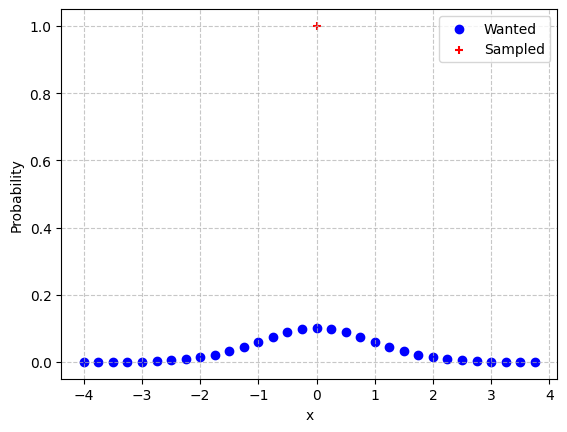

In [15]:
import numpy as np
from classiq import *
from classiq.qmod import *
from classiq.qmod.symbolic import exp  # Import symbolic functions
from classiq.execution import ExecutionPreferences

NUM_QUBITS = 5
SIGNED = True
FRACTION_DIGITS = NUM_QUBITS - 3
EXP_RATE = 1/2

# Generate the Gaussian probability distribution
grid = np.linspace(-4, 4 - 8 / (2**NUM_QUBITS), 2**(NUM_QUBITS))
wanted_gaussian = np.exp(-EXP_RATE * grid**2)
wanted_gaussian /= np.sum(wanted_gaussian)  # Normalize

@qfunc
def prepare_gaussian_funcion_amplitude_loading(x: QNum, ind: QBit):
    """Applies amplitude encoding to load the Gaussian distribution into the indicator qubit."""
    ind *= exp(-EXP_RATE * x**2)  # Assigns the amplitude function to the indicator qubit

@qfunc
def main(x: Output[QNum[NUM_QUBITS, SIGNED, FRACTION_DIGITS]], ind: Output[QBit]):
    allocate(x)
    allocate(ind)

    # Prepare Gaussian state using amplitude loading
    prepare_gaussian_funcion_amplitude_loading(x, ind)

# Generate the quantum model with constraints
qmod = create_model(main,
                    execution_preferences=ExecutionPreferences(num_shots=1000000),
                    constraints=Constraints(max_width=25))

# Synthesize and execute the quantum program
qprog = synthesize(qmod)
res = execute(qprog).get_sample_result()

# Post-select on ind=1 (ensuring only desired Gaussian distribution is analyzed)
parsed_counts = [sample for sample in res.parsed_counts if sample.state['ind']]

# Verify the distribution
def verify_results(parsed_counts, num_qubits):
    EXP_RATE = 1/2
    
    grid = np.linspace(-4, 4 - 8 / (2**num_qubits), 2**(num_qubits))
    wanted_gaussian = np.exp(-EXP_RATE * grid**2)
    wanted_gaussian /= np.sum(wanted_gaussian)  # Normalize

    x = [sample.state['x'] for sample in parsed_counts]
    probs = np.array([sample.shots for sample in parsed_counts])
    probs = probs / probs.sum()
    
    import matplotlib.pyplot as plt
    plt.scatter(grid, wanted_gaussian, color='blue', label="Wanted")
    plt.scatter(x, probs, color='red', marker='+', label="Sampled")
    plt.xlabel('x')
    plt.ylabel('Probability')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Run verification
verify_results(parsed_counts, NUM_QUBITS)

### Part C: a scalable implementation!

This part is **optional**. Completing it will guarantee some points in the *creativity* category.

So the previous part was still non-scalable, as the general amplitude function has exponential cost in the number of qubits. We now leverage both digital and analog quantum transformations to implement the same transformation as in part B. The idea is, given a state $|x\rangle$, to calculate $|x\rangle|x^2\rangle$. Then implement amplitude loading of a gaussian state in order to get $|x\rangle|x^2\rangle(e^{-0.5x^2}|00...0\rangle + ...)$.

**Task**: First think how to efficiently implement amplitude loading of an exponent using the same number of indicator qubits as the number input qubits (hint: think about decomposition of the exponent according to the binary representation).

In [13]:
@qfunc
def exponential_amplitude_loading(exp_rate: CReal, y: QArray[QBit], ind: QArray[QBit]):
    """Loads the Gaussian function using an efficient exponent representation."""
    for i in range(len(y)):
        ind[i] *= exp(-exp_rate * 2**i)  # Encode exponent using binary representation

Now use this primitive and digital transformation in order to load the gaussian state, as done in part B:

In [ ]:
import numpy as np
from classiq import *
from classiq.qmod import *
from classiq.qmod.symbolic import exp
from classiq.execution import ExecutionPreferences

NUM_QUBITS = 5
SIGNED = True
FRACTION_DIGITS = NUM_QUBITS - 3
EXP_RATE = 0.5

@qfunc
def compute_x_squared(x: QNum, y: QNum):
    """Computes y = x^2 using quantum arithmetic."""
    assign(y, mul(x, x))  # Efficient squaring operation

@qfunc
def exponential_amplitude_loading(exp_rate: CReal, y: QNum, ind: QArray[QBit]):
    """Loads the Gaussian function using an efficient exponent representation."""
    for i in range(len(ind)):  
        ind[i] *= exp(-exp_rate * y * 2**(-i))  # Apply exponent transformation

@qfunc
def prepare_gaussian_funcion_scalable(x: QNum[NUM_QUBITS, SIGNED, FRACTION_DIGITS], ind: QArray[QBit]):
    """Efficiently loads a Gaussian distribution using a scalable digital transformation."""
    y = QNum[2 * NUM_QUBITS - 1, SIGNED, 2 * FRACTION_DIGITS]()  # Output register for x^2
    allocate(y)

    # Compute x^2
    compute_x_squared((x * x), y)

    # Apply amplitude encoding using indicator qubits
    exponential_amplitude_loading(EXP_RATE, y, ind)

@qfunc
def main(x: Output[QNum[NUM_QUBITS, SIGNED, FRACTION_DIGITS]], ind: Output[QArray[QBit]]):
    allocate(x)
    allocate(ind, size=2*x.size-1)  # Corrected allocation syntax
    
    # Prepare Gaussian state
    prepare_gaussian_funcion_scalable(x, ind)

# Generate the quantum model with constraints
qmod = create_model(main,
                    execution_preferences=ExecutionPreferences(num_shots=1000000),
                    constraints=Constraints(max_width=25))

# Synthesize the quantum program
qprog = synthesize(qmod)
res = execute(qprog).get_sample_result()

# Post-select for ind=0,0,0,...,0
parsed_counts = [sample for sample in res.parsed_counts if np.sum(sample.state['ind']) == 0]

# Verify results
def verify_results(parsed_counts, num_qubits):
    EXP_RATE = 1/2
    
    grid = np.linspace(-4, 4 - 8 / (2**num_qubits), 2**(num_qubits))
    wanted_gaussian = np.exp(-EXP_RATE * grid**2)
    wanted_gaussian /= np.sum(wanted_gaussian)  # Normalize

    x = [sample.state['x'] for sample in parsed_counts]
    probs = np.array([sample.shots for sample in parsed_counts])
    probs = probs / probs.sum()
    
    import matplotlib.pyplot as plt
    plt.scatter(grid, wanted_gaussian, color='blue', label="Wanted")
    plt.scatter(x, probs, color='red', marker='+', label="Sampled")
    plt.xlabel('x')
    plt.ylabel('Probability')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

verify_results(parsed_counts, NUM_QUBITS)


SyntaxError: unterminated string literal (detected at line 72) (707649553.py, line 72)